# Analysis Data
Notebook for the analysis of the data collected in 4 rounds of 5000 executed tasks each of 6 different models on the same OS and infrastructure setup.

In [16]:
import os
import sys
import re
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [11]:
PERIOD_US = {"tight": 10_000, "soft": 100_000}
PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e",
           "#17becf", "#8c564b", "#e377c2", "#bcbd22", "#7f7f7f"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]

def style(i):
    return PALETTE[i % len(PALETTE)], MARKERS[i % len(MARKERS)]

### Unify dataset into one

In [3]:
path = "./analysis/data"
empty = True

for _ in os.scandir(path):
    empty = False
    break
if empty:
    origin_data = "./results"
    models = ["model1", "model3-phys-cfs", "model3-phys-res", "model3-sib-cfs", "model3-sib-res", "model4"]
    for model in models:
        pieces = [] 
        for round_n in range(1, 5):
            round_dir = os.path.join(origin_data, f"{model}_round{round_n}")
            if not os.path.isdir(round_dir):
                print(f"  {model} round{round_n}: no results dir, skipping")
                continue 
            for csv_path in sorted(glob.glob(os.path.join(round_dir, "*", "*", "jobs.csv"))):
                m = re.search(r"/([^/]+)/U([^/]+)/jobs\.csv$", csv_path)
                if not m:
                    print(f"  WARNING: unexpected path shape, skipping: {csv_path}")
                    continue
                scale, u = m.group(1), m.group(2)
                try:
                    df = pd.read_csv(csv_path, comment="#")
                except Exception as e:
                    print(f"  WARNING: could not read {csv_path}: {e}")
                    continue
                if df.empty:
                    print(f"  WARNING: empty csv, skipping: {csv_path}")
                    continue
                df["model"] = model
                df["round"] = round_n
                df["scale"] = scale
                df["U"] = float(u)
                pieces.append(df)

        if not pieces:
            print(f"  {model}: no data found across any round, skipping save")
            continue

        combined_dataset = pd.concat(pieces, ignore_index=True)
        combined_dataset.to_csv(os.path.join(path, f"{model}.csv"), index=False)
        print(f"Saved combined dataset for model: {model} ({len(combined_dataset)} rows, "
            f"{combined_dataset['round'].nunique()} round(s))")


## Point 1: Cloud Noise Floor
At OS-level, we have applied all possible configurations to enable stability of the executions and isolation of the cores from other tasks. Whatever is left, is noise floor persistnt with this setup that we cannot remove.

The variability is represented by the metric **cv = std / mean** and this is applied to both **Execution Time (C)** and **Response Time (R)**.

In [7]:
model1 = pd.read_csv(os.path.join(path, "model1.csv"))                                                                                                                                      
rows = []                                                                                                                                                                                   
for (scale, u), g in model1.groupby(["scale", "U"]):                                                                                                                                        
    for col, label in [("C_cputime_us", "C"), ("R_wall_us", "R")]:                                                                                                                          
        s = g[col] / 1000.0   # us -> ms
        print(type(round))                                                                                                                                                     
        rows.append({                                                                                                                                                                       
            "scale": scale, "U": u, "metric": label,                                                                                                                                       
            "mean_ms": round(s.mean(), 3), "std_ms": round(s.std(), 3),
            "cv": round(s.std() / s.mean(), 4) if s.mean() else None,
        })
noise_floor_table = pd.DataFrame(rows).sort_values(["scale", "U", "metric"])
noise_floor_table

<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<class 'builtin_function_or_method'>
<

,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.796,0.707,0.0906
1,soft,0.10,R,8.421,6.881,0.8171
2,soft,0.20,C,14.692,0.642,0.0437
3,soft,0.20,R,14.946,1.764,0.1180
4,soft,0.30,C,22.014,0.751,0.0341
5,soft,0.30,R,22.271,2.842,0.1276
6,soft,0.40,C,28.871,1.094,0.0379
7,soft,0.40,R,29.103,2.762,0.0949
8,soft,0.50,C,35.644,0.842,0.0236
9,soft,0.50,R,35.775,1.298,0.0363


#### Analyse correlation between execution time variance and nonvol_ctxt and mid_job_preempt_us

In [5]:
rows = []
for (scale, u), g in model1.groupby(["scale", "U"]):
        rows.append({
            "scale": scale, "U": u,
            "nonvol_pct_nonzero": round(100 * (g["nonvol_ctxt"] > 0).mean(), 3),
            "nonvol_max": int(g["nonvol_ctxt"].max()),
            "midjob_max_us": round(g["mid_job_preempt_us"].max(), 1),
        })
t = pd.DataFrame(rows)
print(f"corr(nonvol_pct_nonzero, midjob_max_us) =", round(t["nonvol_pct_nonzero"].corr(t["midjob_max_us"]), 3))                                                                                                                       
print(f"corr(nonvol_max, midjob_max_us) =", round(t["nonvol_max"].corr(t["midjob_max_us"]), 3))

corr(nonvol_pct_nonzero, midjob_max_us) = 0.169
corr(nonvol_max, midjob_max_us) = -0.01


#### Analyse distribution of noise floor

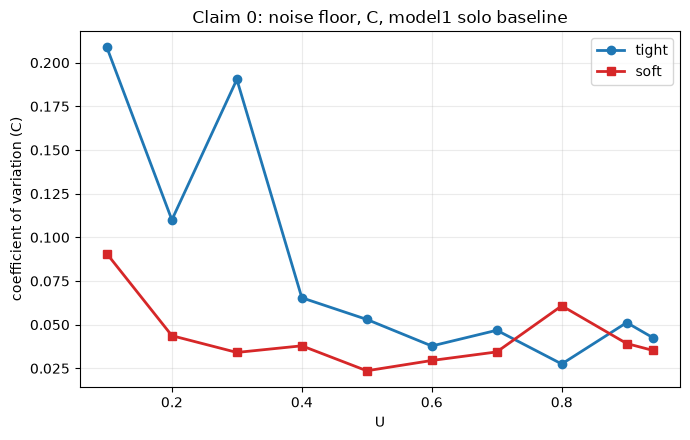

In [14]:
noise_floor_table
t = noise_floor_table[noise_floor_table["metric"] == "C"]
scales = sorted(t["scale"].unique(), key=lambda s: PERIOD_US[s])
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, scale in enumerate(scales):
    g = t[t.scale == scale].sort_values("U")
    c, m = style(i)
    ax.plot(g["U"], g["cv"], color=c, marker=m, markersize=6, linewidth=2, label=scale)
ax.set_xlabel("U"); ax.set_ylabel(f"coefficient of variation ({"C"})")
ax.set_title(f"Claim 0: noise floor, {"C"}, model1 solo baseline")
ax.grid(alpha=0.25); ax.legend()
fig.tight_layout()

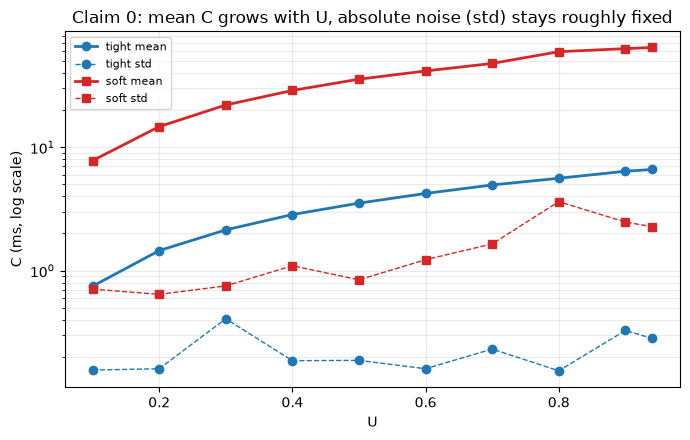

In [ ]:
t = noise_floor_table[noise_floor_table["metric"] == "C"]
scales = sorted(t["scale"].unique(), key=lambda s: PERIOD_US[s])
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, scale in enumerate(scales):
    g = t[t.scale == scale].sort_values("U")
    c, m = style(i)
    ax.plot(g["U"], g["mean_ms"], color=c, marker=m, markersize=6, linewidth=2, label=f"{scale} mean")
    ax.plot(g["U"], g["std_ms"], color=c, marker=m, markersize=6, linewidth=1, linestyle="--", label=f"{scale} std")
ax.set_yscale("log")
ax.set_xlabel("U"); ax.set_ylabel("C (ms, log scale)")
ax.set_title("Claim 0: mean C grows with U, absolute noise (std) stays roughly fixed")
ax.grid(alpha=0.25, which="both"); ax.legend(fontsize=8)
fig.tight_layout()
